Created on 2026.01.27

Description: Exploratory analysis of 6 xenium samples data after CellTypist labelling. 
Goal is to first check cell labelling.

@author: bellwu

In [ ]:
# %% ---- 1.0 import libraries ----
import scanpy as sc
from pyxenium import xen_config as xc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# %% load path and directories
xen_dir = xc.xen_bwu
# load as dictionary
adata_64312 = sc.read_h5ad(xen_dir / "SCLC_64312_pp_CellTypist_labeled.h5ad")
# labeled_adatas = {p.stem: sc.read_h5ad(p) for p in xen_dir.glob("*CellTypist_labeled.h5ad")}

Want to check first sample to see how the values look. 
- Will first test on adata_64312

In [ ]:
# %% ---- 2.0 check ----
adata_64312.obs.columns
over_clustering = adata_64312.obs['over_clustering'].head(10)
pred_labels = adata_64312.obs['predicted_labels'].head(10)
maj_vote = adata_64312.obs['majority_voting'].head(10)
conf_score = adata_64312.obs['conf_score'].head(10)
print(over_clustering)
print(pred_labels)
print(maj_vote)
print(conf_score)

From values:
- overclustering gives the cluster that the cell was computationally associated with before further leiden clustering to reference
- majority voting, predicted label = gives the cell annotated type
- conf_score gives confidence voting system was

In [ ]:
adata_64312.uns

In [ ]:
adata_64312.obs.columns

In [ ]:
adata_64312.var.columns

In [ ]:
adata_64312.obs['predicted_labels'].value_counts()

In [ ]:
sc.pl.umap(adata_64312, color=['leiden', 'predicted_labels'], wspace=0.5)

In [ ]:
sc.pl.spatial(adata_64312, color=['leiden', 'predicted_labels'], spot_size=20)

Notes on UMAP visualization of leiden clusters:
- 13 clusters only but have 24 predicted labels: this means that multiple labels correspond to the same cluster
- the idea of leiden is it just define unique transcriptomic group:
    - the predicted labels that correspond to the same cluster must mean that there is some issue with differentiating between profile
    - **Need to check which labels correspond to the same cluster**
- manual annotation:
    - involves looking through each individual clusters and their highly expresed genes

In [ ]:
# check which labels correspond to same cluster
# adata_64312.obs.groupby('leiden')['predicted_labels'].unique()

# Cross-tab: rows=leiden, cols=predicted_labels
leiden_freq = pd.crosstab(adata_64312.obs['leiden'], adata_64312.obs['predicted_labels'], 
                          normalize='index').mul(100).round(2)
leiden_freq
# select top label
# pd.DataFrame({
#     'top_label': leiden_freq.idxmax(axis=1),
#     'pct': leiden_freq.max(axis=1)
# })

###### Annotation from CellTypist
Looking at cross-tabulation frequencies
- lots of "contamination across clusters": goes to show the label transfer is doing a really bad job at correlating to cluster
    - potentially need to look at coarse populations and then go more granular?
    - options to move forward:
        1) manually label based on gene expression
        2) adjust labelling based on frequencies
        3) use the frequencies as a starting point to define the cluster (the highest labeled cell population in this cluster is likely this)
###### Mixed annotation:
- try to implement a mixed tactic where I see how good the manual is for only one cell type (immune cells)
- tease out what each leiden cluster is looking at gene expression:
    - test with T cells by confirming the clusters that are immune cells

In [ ]:
# only colour the T cells
adata_64312.obs['t_cell_labels'] = adata_64312.obs['predicted_labels'].where(
    adata_64312.obs['predicted_labels'].str.contains('T cell'), other=None
)

sc.pl.umap(adata_64312, color='t_cell_labels', wspace=0.5)

In [ ]:
# find percentage of T cells out of all cells
t_cells = adata_64312[adata_64312.obs['predicted_labels'].str.contains('T cell')]
percent_t_cells = t_cells.obs['predicted_labels'].value_counts() / adata_64312.n_obs * 100
percent_t_cells

Roughly 15% of all predicted cells are T cells. 
Next want to check how accurate the T cells:
- Do so based on the xenium 5k gene panel: within the panel, the curated lists contains genes that relate to T cells

In [ ]:
# load xenium 5k panel
xen_5k = pd.read_csv(xen_dir / "Xenium5k_Human_Panel.csv")

In [ ]:
# split all cell_type entries at ';' and get unique labels
all_labels = (xen_5k['cell_type']
              .dropna()
              .str.split(';')
              .explode()
              .str.strip()
              .unique())
sorted(all_labels)
# filter for all labels that do not contain T
[label for label in sorted(all_labels) if 'T' not in label]

Looking through the list, it seems that "T" does good job of selecting for only T cell-related genes.

Now need to:
1) select out the genes that are relevant to T cells from the panel.
2) see how many genes are expressed at low levels
    - there are 336 genes expressed that relate to T cells
    - all genes are expressed across cells
3) create a distribution for the clusters to see how many cells in each cluster express these genes
    - start with all 336
    - move down to a the 50% then 75% quantile

In [ ]:
# select out genes that match cell type descriptor "T "
t_cell_genes = xen_5k[xen_5k['cell_type'].str.contains("T ", na=False)]
# select out gene names
t_cell_genes = t_cell_genes['gene_name']
type(t_cell_genes) # outputs series

In [ ]:
# select out gene names as mask
mask = t_cells.var_names.isin(t_cell_genes)
t_cells = t_cells[:, mask]

In [ ]:
# find the total number of genes that each cells express
t_cell_counts = t_cells[t_cell_genes].X.sum(axis=1)

In [ ]:
# find the less expressed genes
t_gene_counts = np.asarray(t_cells.X.sum(axis=0)).flatten()
t_gene_counts = pd.Series(t_gene_counts, index=t_cell_genes, name='count_sums')
# set threshold and filter
threshold = t_gene_counts.describe().loc['75%']
t_gene_counts[t_gene_counts > threshold]

Note the above is a 'dirty' gene set. Meaning that some of these genes do not relate solely to T cells. 

Below will try to select out genes only with T cell

In [ ]:
# select genes that match with term "T cell"
cell_types = xen_5k[['gene_name', 'cell_type']]
cell_types.set_index('gene_name', inplace=True)
cell_types = cell_types['cell_type'].dropna().str.split(';')
cell_types = cell_types[cell_types.apply(lambda x: 'T cell' in x)]
genes = cell_types.index.values
genes

Now that I have these genes, will segregate out again the genes from the anndata and then the T cell labels and compare

In [ ]:
mask = adata_64312.var_names.isin(genes)
adata_tcell = adata_64312[:, mask]
# sum across columns
adata_tcell = adata_tcell.X.toarray().sum(axis=0).flatten()
adata_tcell = pd.Series(adata_tcell, index=genes, name='count_sums')
# create threshold
threshold = adata_tcell.describe().loc['75%']
# select only top genes
adata_top75 = adata_tcell[adata_tcell > threshold]
genes_top75 = adata_top75.index.values
genes_top75

In [ ]:
xen_5k[xen_5k['gene_name'].isin(genes)]

Comparing across the final gene sets:
- amt genes reduced from changing term of "T" into "T cell"
- might use the T selection criteria to start

In [ ]:
# select out all genes from the T cell gene set
mask = adata_64312[:, genes]
n_genes_expressed = np.asarray((mask.X > 0).sum(axis=1)).flatten()
adata_64312.obs['n_genes_in_T_cell_set'] = n_genes_expressed
adata_64312.obs['n_genes_in_T_cell_set'] 

0-7         17
1-7          9
2-7          8
3-7         12
4-7          9
            ..
283728-4     4
283731-4     1
283733-4     2
283742-4     2
283747-4     4
Name: n_genes_in_T_cell_set, Length: 252794, dtype: int64

/var/folders/rj/9llnws051r50ch72ms9x2btr0000gn/T/ipykernel_71342/1443737148.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for cluster, group in adata_64312.obs.groupby('leiden'):


<function matplotlib.pyplot.show(close=None, block=None)>

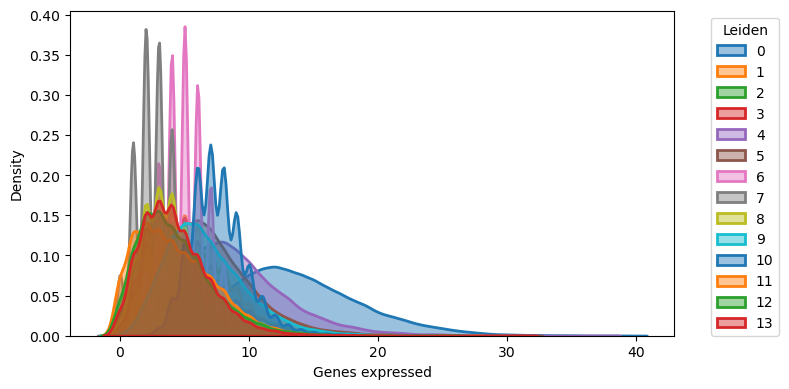

In [ ]:
# plot stacked density plots of the T cell panel

# set plot axis
fig, ax = plt.subplots(figsize=(8, 4))

for cluster, group in adata_64312.obs.groupby('leiden'):
    sns.kdeplot(
        data=group,
        x='n_genes_in_T_cell_set',
        fill=True,
        alpha=0.45,
        linewidth=2,
        label=cluster,
        ax=ax
    )

ax.set_xlabel('Genes expressed')
ax.set_ylabel('Density')
ax.legend(title='Leiden', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show

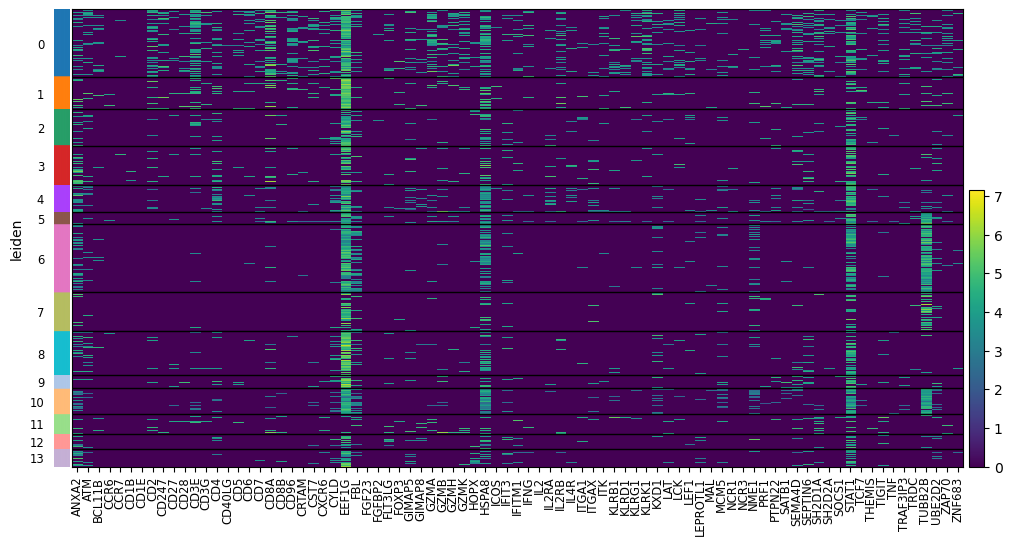

In [196]:
# create heatmap
sc.pl.heatmap(adata_64312, var_names=genes, groupby='leiden', show_gene_labels=True, figsize=(12, 6))